In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap


df_interactions = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/clustered-interactions_pt2/cropped_interactions.csv')

df_cluster = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/clustered-interactions_pt2/F15_KMAX3_DMAX4_NMIN1500--/pca-data3-F15-mcmodels4-Kmax3-Dmax4-Nmin1500-05-2026.csv')

df =  pd.merge(
            df_interactions, 
            df_cluster[['interaction_id', 'Yhat.idt.pca']], 
            on='interaction_id', 
            how='inner'
        )

# keep only the example interaction
df = df[df['interaction_id'] == 'S_2268'].sort_values('Normalized Frame').reset_index(drop=True)


In [16]:
## TRACE STYLE (same look as FIGURE-2/gh-v-iso-interaction.ipynb), head only

from scipy.interpolate import splprep, splev

CORE_LW = 0.6
HALO_W = 5      # thinner than FIGURE-2 (8) because these panels are smaller
N_HALO = 16
HALO_ALPHA = 0.045
HALO_TINT = 0.55
CONTRAST = 3.0
SPLINE_PTS = 600

mpl.rcParams.update({'pdf.fonttype': 42, 'ps.fonttype': 42, 'svg.fonttype': 'none',
                     'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

CMAPS = {1: LinearSegmentedColormap.from_list('t1', ['#c7e9c0', '#41ab5d', '#00441b']),   # green
         2: LinearSegmentedColormap.from_list('t2', ['#dadaeb', '#9e9ac8', '#54278f'])}   # purple


def ramp(t):
    t = np.clip(t, 0, 1)
    return t ** CONTRAST / (t ** CONTRAST + (1 - t) ** CONTRAST + 1e-12)


def lighten(cols):
    out = cols.copy()
    out[:, :3] = out[:, :3] + (1 - out[:, :3]) * HALO_TINT
    return out


def spline(pts):
    keep = np.r_[True, (np.diff(pts, axis=0) ** 2).sum(1) > 1e-12]
    pts = pts[keep]
    tck, u = splprep(pts.T, s=0, k=min(3, len(pts) - 1))
    ue = np.linspace(0, 1, SPLINE_PTS)
    xy = np.column_stack(splev(ue, tck))
    return xy, np.interp(ue, u, np.linspace(0, 1, len(pts)))


def trace_head(ax, ex, tr):
    pts = ex[[f'mm_Track_{tr} x_head', f'mm_Track_{tr} y_head']].dropna().values
    xy, t = spline(pts)
    segs = np.stack([xy[:-1], xy[1:]], axis=1)
    cols = CMAPS[tr](ramp(t[:-1]))
    pale = lighten(cols)
    for w in np.linspace(HALO_W, CORE_LW * 1.5, N_HALO):
        ax.add_collection(LineCollection(segs, colors=pale, linewidths=w, alpha=HALO_ALPHA,
                                         capstyle='round', joinstyle='round', zorder=2))
    ax.add_collection(LineCollection(segs, colors=cols, linewidths=CORE_LW,
                                     capstyle='round', joinstyle='round', zorder=3))


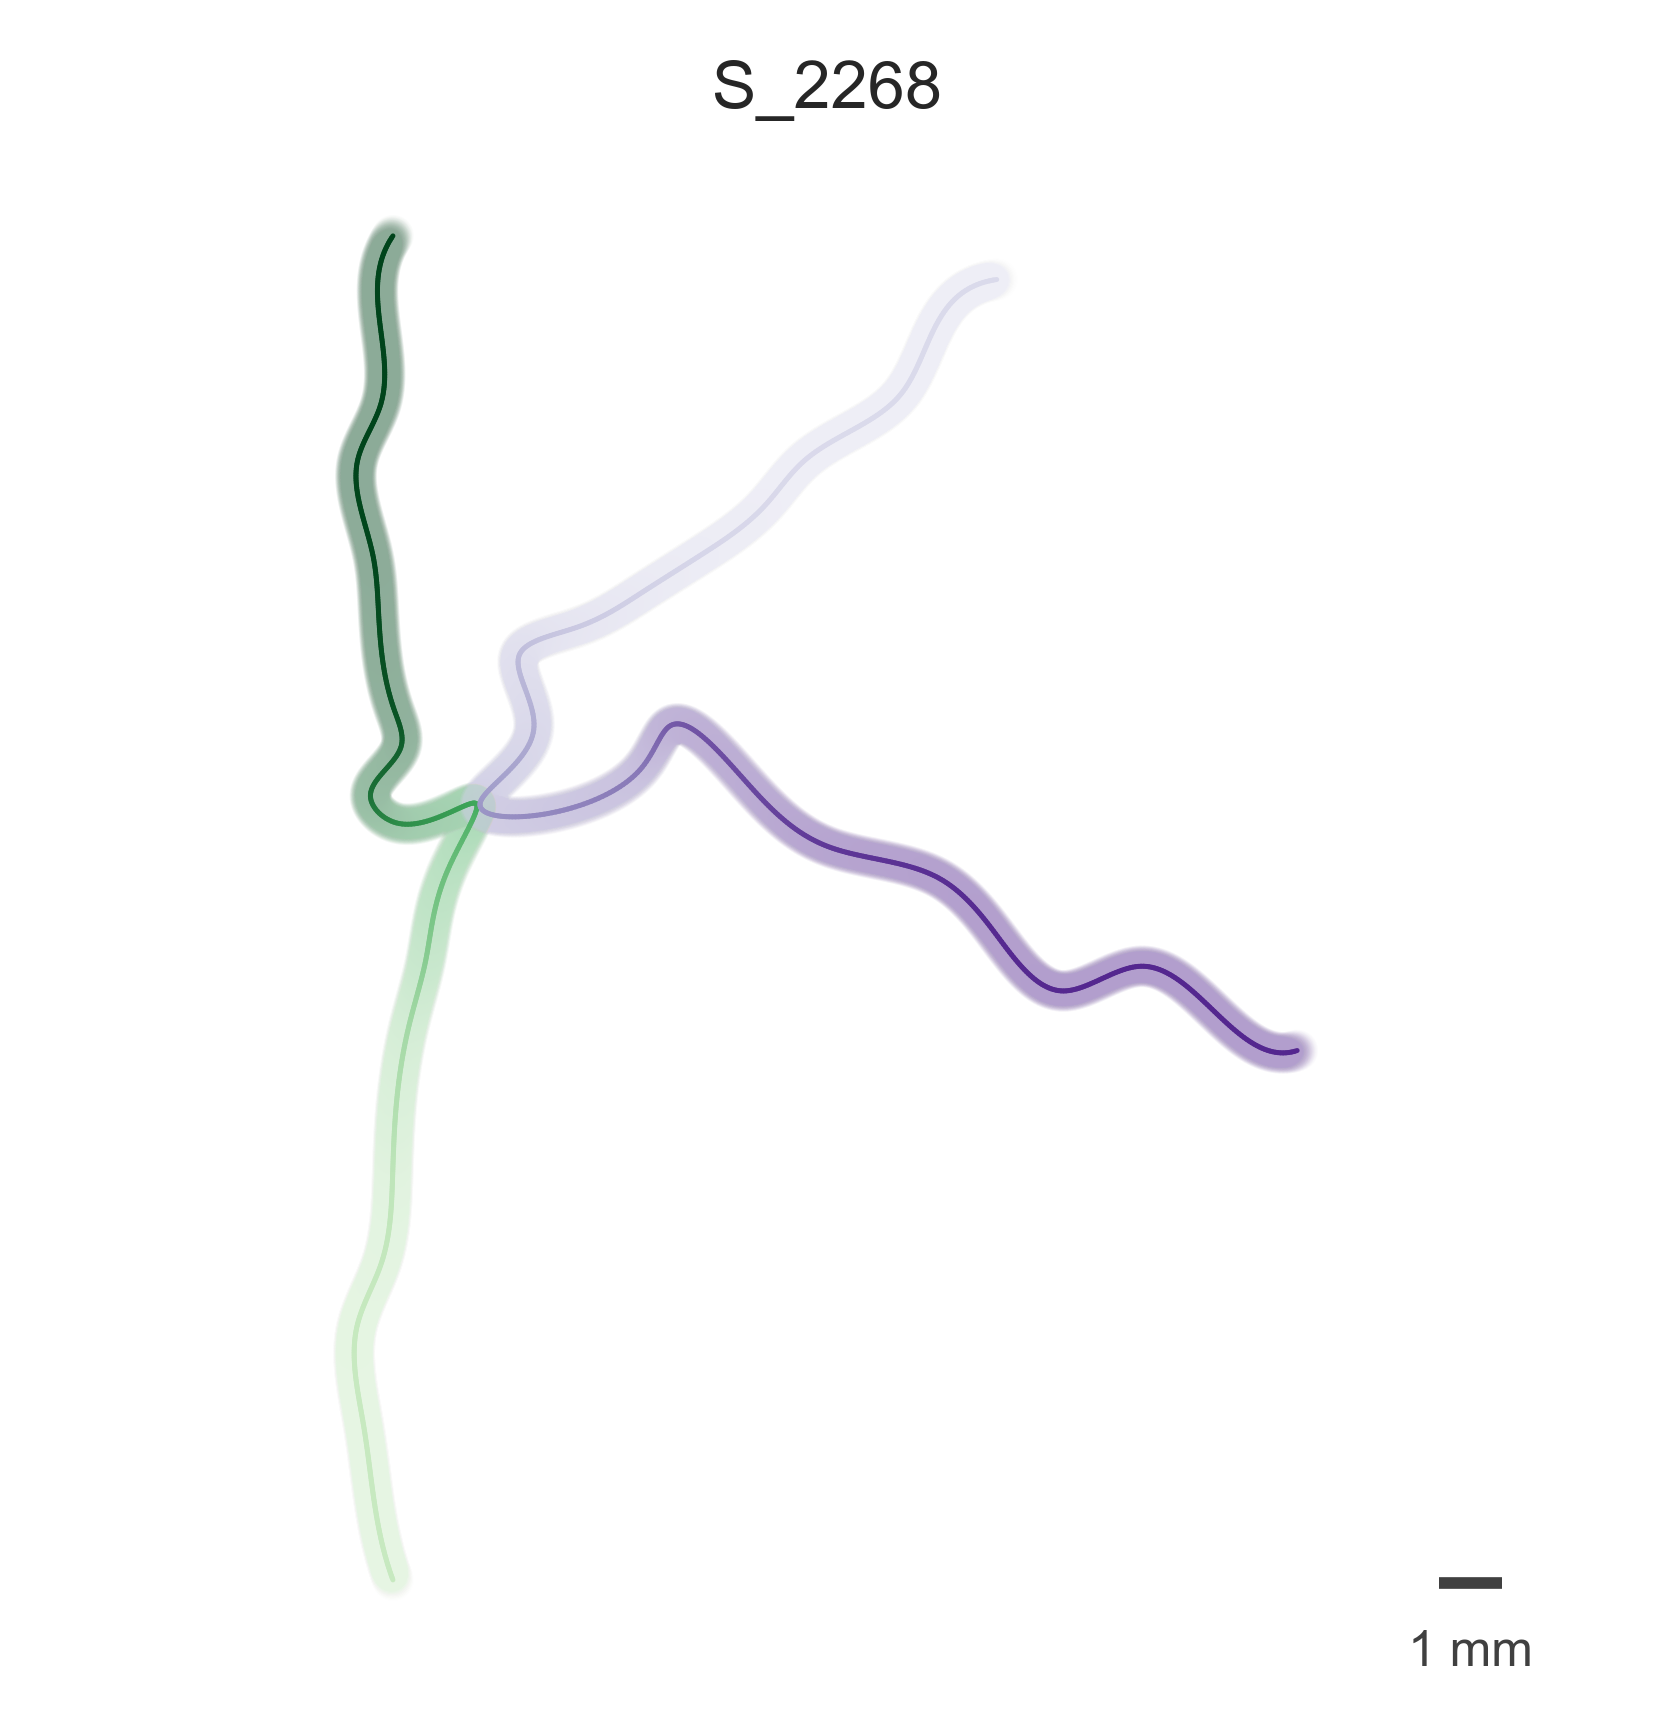

In [17]:
## EXAMPLE INTERACTION -- head trajectories

%config InlineBackend.figure_format = 'retina'


def scale_bar(ax):
    MM = 1
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    bx = x1 - 0.06 * (x1 - x0); by = y0 + 0.06 * (y1 - y0)
    ax.plot([bx - MM, bx], [by, by], color='0.25', lw=1.4, solid_capstyle='butt', zorder=6)
    ax.text(bx - MM / 2, by - 0.03 * (y1 - y0), f'{MM} mm', ha='center', va='top',
            fontsize=6, color='0.25')


def draw_example():
    SAVE = '/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/FIGURE-3/example-interaction-S_2268'   # saves .pdf and .png
    PANEL_IN = 3
    DPI = 300
    PAD_MM = 1.5

    ex = df.copy()

    # rotate so track 1 (green) runs from bottom (start) to top (end)
    start = ex[['mm_Track_1 x_head', 'mm_Track_1 y_head']].values[0]
    end = ex[['mm_Track_1 x_head', 'mm_Track_1 y_head']].values[-1]
    angle = np.pi / 2 - np.arctan2(end[1] - start[1], end[0] - start[0])
    R = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
    for tr in (1, 2):
        cols = [f'mm_Track_{tr} x_head', f'mm_Track_{tr} y_head']
        ex[cols] = (ex[cols].values - start) @ R.T

    fig, ax = plt.subplots(figsize=(PANEL_IN, PANEL_IN), dpi=DPI)
    for tr in (1, 2):
        trace_head(ax, ex, tr)

    xs = ex[['mm_Track_1 x_head', 'mm_Track_2 x_head']].values.ravel()
    ys = ex[['mm_Track_1 y_head', 'mm_Track_2 y_head']].values.ravel()
    cx, cy = (np.nanmax(xs) + np.nanmin(xs)) / 2, (np.nanmax(ys) + np.nanmin(ys)) / 2
    half = (max(np.nanmax(xs) - np.nanmin(xs), np.nanmax(ys) - np.nanmin(ys)) + 2 * PAD_MM) / 2
    ax.set_xlim(cx - half, cx + half); ax.set_ylim(cy - half, cy + half)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(ex['interaction_id'].iloc[0], fontsize=8, color='0.15', pad=4)
    scale_bar(ax)

    plt.tight_layout()
    if SAVE:
        fig.savefig(SAVE + '.pdf', bbox_inches='tight')
        fig.savefig(SAVE + '.png', dpi=600, bbox_inches='tight')
    plt.show()


draw_example()


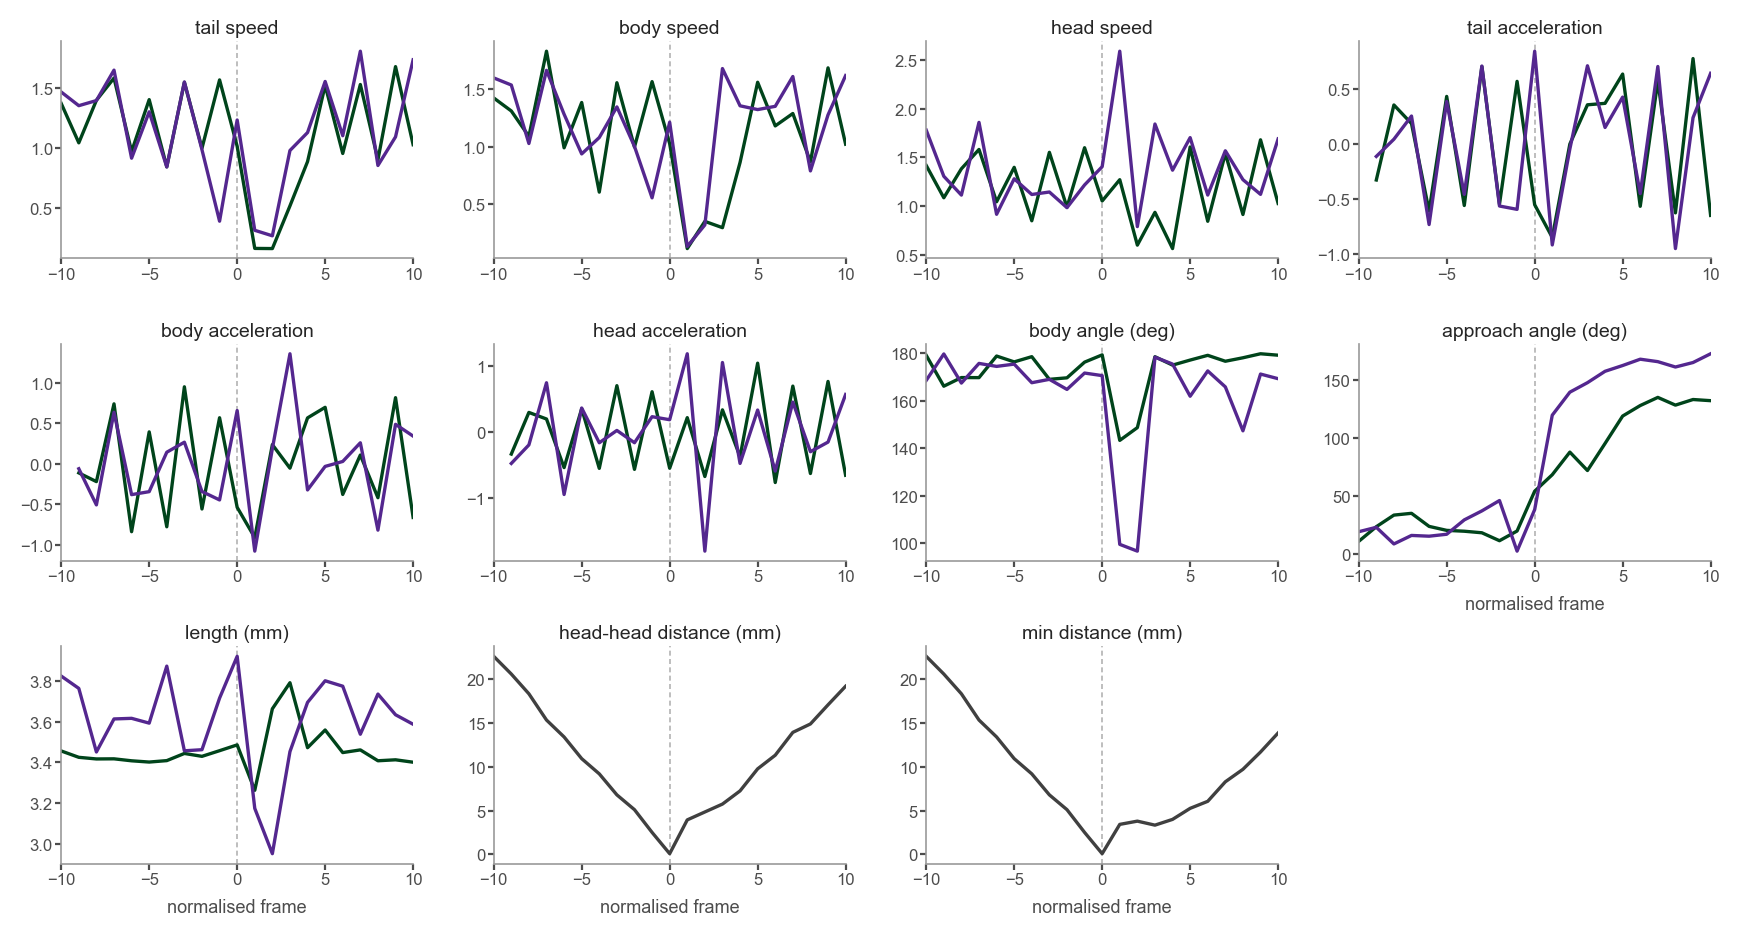

In [18]:
## FEATURES OVER TIME -- green = track 1, purple = track 2

%config InlineBackend.figure_format = 'retina'


def draw_features():
    GREEN = '#00441b'
    PURPLE = '#54278f'
    PAIR_COLOUR = '0.25'     # for measures shared by both larvae (e.g. head-head distance)
    N_COLS = 4
    PANEL_W_IN = 2.2
    PANEL_H_IN = 1.6
    SAVE = '/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/FIGURE-3/example-interaction-S_2268-features'   # saves .pdf and .png

    # (title, track 1 column, track 2 column) -- one column only = shared by the pair
    PANELS = [
        ('tail speed',          'track1_speed_tail',        'track2_speed_tail'),
        ('body speed',          'track1_speed_body',        'track2_speed_body'),
        ('head speed',          'track1_speed_head',        'track2_speed_head'),
        ('tail acceleration',   'track1_acceleration_tail', 'track2_acceleration_tail'),
        ('body acceleration',   'track1_acceleration_body', 'track2_acceleration_body'),
        ('head acceleration',   'track1_acceleration_head', 'track2_acceleration_head'),
        ('body angle (deg)',    'track1_angle',             'track2_angle'),
        ('approach angle (deg)','track1_approach_angle',    'track2_approach_angle'),
        ('length (mm)',         'track1_length',            'track2_length'),
        ('head-head distance (mm)', 't1_head-head_t2'),
        ('min distance (mm)',   'min_distance'),
    ]

    d = df.sort_values('Normalized Frame')
    t = d['Normalized Frame']

    n_rows = int(np.ceil(len(PANELS) / N_COLS))
    fig, axes = plt.subplots(n_rows, N_COLS, figsize=(N_COLS * PANEL_W_IN, n_rows * PANEL_H_IN))

    for ax, panel in zip(axes.flat, PANELS):
        title, cols = panel[0], panel[1:]
        if len(cols) == 2:
            ax.plot(t, d[cols[0]], color=GREEN, lw=1.2)
            ax.plot(t, d[cols[1]], color=PURPLE, lw=1.2)
        else:
            ax.plot(t, d[cols[0]], color=PAIR_COLOUR, lw=1.2)
        ax.axvline(0, color='0.7', lw=0.6, ls=(0, (3, 2)), zorder=0)
        ax.set_title(title, fontsize=7, color='0.15', pad=3)
        ax.set_xlim(t.min(), t.max())
        ax.tick_params(labelsize=6, length=2, pad=1, colors='0.3')
        for sp in ('top', 'right'):
            ax.spines[sp].set_visible(False)
        for sp in ('left', 'bottom'):
            ax.spines[sp].set_color('0.6'); ax.spines[sp].set_linewidth(0.6)

    for ax in axes.flat[len(PANELS):]:
        ax.axis('off')
    for ax in axes.flat[len(PANELS) - N_COLS:len(PANELS)]:     # bottom panel of each column
        ax.set_xlabel('normalised frame', fontsize=6.5, color='0.3')

    plt.tight_layout()
    if SAVE:
        fig.savefig(SAVE + '.pdf', bbox_inches='tight')
    plt.show()


draw_features()


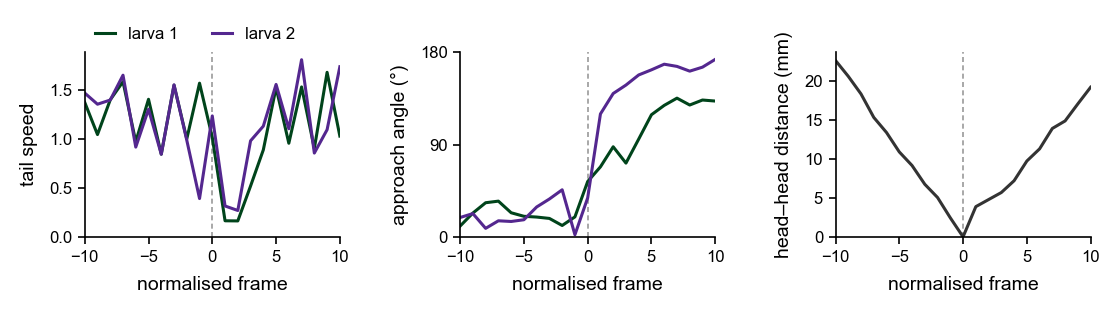

In [19]:
## FIGURE PANEL -- tail speed, approach angle, head-head distance

%config InlineBackend.figure_format = 'retina'


def draw_feature_panel():
    GREEN = '#00441b'
    PURPLE = '#54278f'
    PAIR_COLOUR = '0.2'
    PANEL_W_IN = 1.9
    PANEL_H_IN = 1.7
    LW = 1.1
    FONT = 7
    SAVE = '/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/FIGURE-3/example-interaction-S_2268-panel'   # saves .pdf and .png

    d = df.sort_values('Normalized Frame')
    t = d['Normalized Frame']

    fig, axes = plt.subplots(1, 3, figsize=(3 * PANEL_W_IN, PANEL_H_IN))

    # tail speed
    ax = axes[0]
    ax.plot(t, d['track1_speed_tail'], color=GREEN, lw=LW, label='larva 1')
    ax.plot(t, d['track2_speed_tail'], color=PURPLE, lw=LW, label='larva 2')
    ax.set_ylabel('tail speed', fontsize=FONT)
    ax.set_ylim(bottom=0)
    ax.legend(frameon=False, fontsize=FONT - 1, loc='lower left', bbox_to_anchor=(0, 1.0),
              ncol=2, handlelength=1.2, borderaxespad=0.2)

    # approach angle
    ax = axes[1]
    ax.plot(t, d['track1_approach_angle'], color=GREEN, lw=LW)
    ax.plot(t, d['track2_approach_angle'], color=PURPLE, lw=LW)
    ax.set_ylabel('approach angle (°)', fontsize=FONT)
    ax.set_ylim(0, 180)
    ax.set_yticks([0, 90, 180])

    # head-head distance
    ax = axes[2]
    ax.plot(t, d['t1_head-head_t2'], color=PAIR_COLOUR, lw=LW)
    ax.set_ylabel('head–head distance (mm)', fontsize=FONT)
    ax.set_ylim(bottom=0)

    for ax in axes:
        ax.axvline(0, color='0.6', lw=0.6, ls=(0, (3, 2)), zorder=0)
        ax.set_xlim(t.min(), t.max())
        ax.set_xticks([-10, -5, 0, 5, 10])
        ax.set_xlabel('normalised frame', fontsize=FONT)
        ax.tick_params(labelsize=FONT - 1, length=2.5, width=0.6, pad=2, direction='out')
        for sp in ('top', 'right'):
            ax.spines[sp].set_visible(False)
        for sp in ('left', 'bottom'):
            ax.spines[sp].set_linewidth(0.6)

    plt.tight_layout(w_pad=1.5)
    if SAVE:
        fig.savefig(SAVE + '.pdf', bbox_inches='tight')
    plt.show()


draw_feature_panel()
